In [20]:
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
clientes = pd.read_csv('../data/clientes.csv')
clientes.head()



,CLIENTE_ID,NOMBRE,APELLIDO,EMAIL,GENERO,FECHA_REGISTRO,CIUDAD,PAIS
0,1,kevin,ortiz,kevin@email.com,masculino,10/01/24,Guatemala,Guatemala
1,2,Juan,Pérez,juan@empresa.com,Masculino,10/01/24,Guatemala,Guatemala
2,3,Carlos,Ramirez,carlos@logisticaexpress.com,Masculino,10/02/24,Escuintla,Guatemala
3,4,Ana,Morales,ana@transportesmorales.com,Femenino,18/02/24,Mixco,Guatemala
4,5,Luis,Castillo,luis@cargacentral.com,Masculino,05/03/24,Villa Nueva,Guatemala


In [7]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CLIENTE_ID      10 non-null     int64
 1   NOMBRE          10 non-null     str  
 2   APELLIDO        10 non-null     str  
 3   EMAIL           10 non-null     str  
 4   GENERO          10 non-null     str  
 5   FECHA_REGISTRO  10 non-null     str  
 6   CIUDAD          10 non-null     str  
 7   PAIS            10 non-null     str  
dtypes: int64(1), str(7)
memory usage: 772.0 bytes


In [8]:
clientes.shape

(10, 8)

In [9]:
len(clientes)

10

In [10]:
clientes.describe()

,CLIENTE_ID
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


In [14]:
categorias = pd.read_csv('../data/categoria.csv')
detallesOrdenes = pd.read_csv('../data/detalleOrden.csv')
ordenes = pd.read_csv('../data/ordenes.csv')
productos = pd.read_csv('../data/productos.csv')

In [18]:

ordenes.groupby("METODO_PAGO")["ORDEN_ID"].count()

METODO_PAGO
Efectivo          5
Tarjeta           5
Transferencia    10
Name: ORDEN_ID, dtype: int64

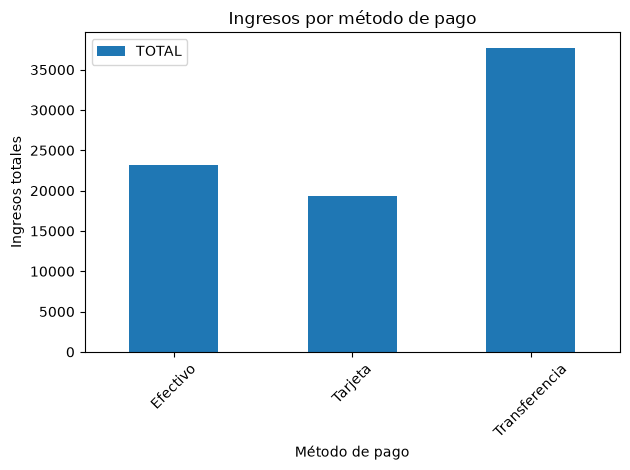

In [21]:
ingresosPagos = ordenes.groupby("METODO_PAGO")["TOTAL"].sum().reset_index()

ingresosPagos.plot(x="METODO_PAGO", y="TOTAL", kind="bar")

plt.title("Ingresos por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Ingresos totales")  
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()



In [25]:
detalleProductos = detallesOrdenes.merge(productos, on='PRODUCTO_ID')

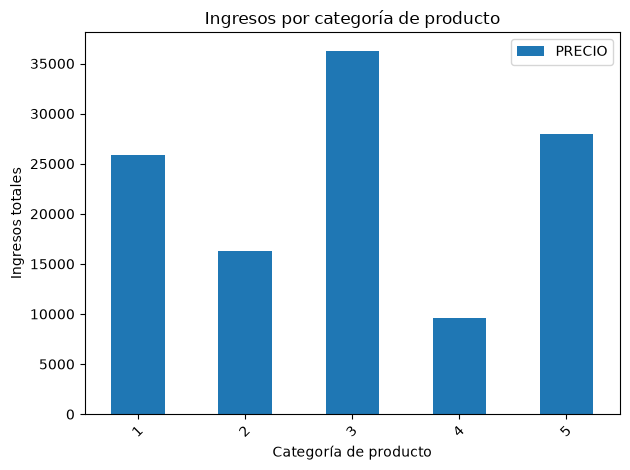

In [26]:
ingresosServicios = detalleProductos.groupby("CATEGORIA_ID")["PRECIO"].sum().reset_index()

ingresosServicios.plot(x="CATEGORIA_ID", y="PRECIO", kind="bar")

plt.title("Ingresos por categoría de producto")
plt.xlabel("Categoría de producto") 
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

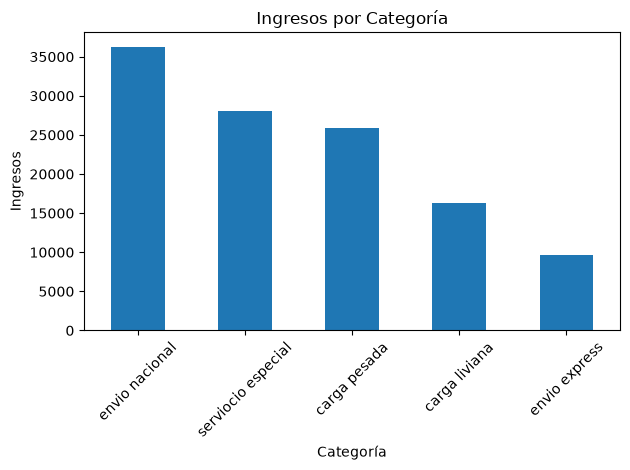

In [ ]:
detalleProductosCategorias = detalleProductos.merge(categorias, on='CATEGORIA_ID')
ingresosServiciosCategorias = detalleProductosCategorias.groupby("NOMBRE_CATEGORIA")["PRECIO"].sum().reset_index()

ingresosServiciosCategorias.plot(x="NOMBRE_CATEGORIA", y="PRECIO", kind="bar")

plt.title("Ingresos por categoría de producto")
plt.xlabel("Categoría de producto")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()